In [1]:

import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
image_datsets = r"C:\Users\User\.cache\kagglehub\datasets\msambare\fer2013\versions\1"
traingen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
testgen=ImageDataGenerator(
    rescale=1./255
)
train_generator=traingen.flow_from_directory(
    os.path.join(image_datsets,"train"),
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical",
    shuffle=True
)
test_generator = testgen.flow_from_directory(
    os.path.join(image_datsets, "test"),
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical",
    shuffle=False
)







Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:

model=models.Sequential([layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(48,48,1)),
                         layers.BatchNormalization(),
                         layers.Conv2D(32,(3,3),padding='same',activation='relu'),
                         layers.BatchNormalization(),
                        layers.MaxPooling2D((2,2)),
                        layers.Dropout(0.25),

                        layers.Conv2D(64,(3,3),padding='same',activation='relu',input_shape=(48,48,1)),
                         layers.BatchNormalization(),
                         layers.Conv2D(64,(3,3),padding='same',activation='relu'),
                         layers.BatchNormalization(),
                        layers.MaxPooling2D((2,2)),
                        layers.Dropout(0.25),
                        
                        layers.Conv2D(128,(3,3),padding='same',activation='relu',input_shape=(48,48,1)),
                         layers.BatchNormalization(),
                         layers.Conv2D(128,(3,3),padding='same',activation='relu'),
                         layers.BatchNormalization(),
                        layers.MaxPooling2D((2,2)),
                        layers.Dropout(0.25),
                         
                         layers.Flatten(),

                         layers.Dense(512,activation='relu'),
                         layers.BatchNormalization(),
                         layers.Dropout(0.5),
                         layers.Dense(7,activation='softmax')
                        ])
model.compile(optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

history=model.fit(train_generator,validation_data=test_generator,epochs=20,callbacks=[reduce_lr])



c:\Users\User\Desktop\ZenithView\ai_engine\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.save("trained.keras")

In [4]:
from tensorflow.keras.models import load_model
model=load_model('trained.keras')

c:\Users\User\Desktop\ZenithView\ai_engine\env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 62 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [5]:
history=model.fit(train_generator,validation_data=test_generator,epochs=40,initial_epoch=20,callbacks=[reduce_lr])

Epoch 21/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 270s 587ms/step - accuracy: 0.6641 - loss: 0.8959 - val_accuracy: 0.6498 - val_loss: 0.9567 - learning_rate: 2.0000e-04
Epoch 22/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 285s 635ms/step - accuracy: 0.6676 - loss: 0.8845 - val_accuracy: 0.6495 - val_loss: 0.9577 - learning_rate: 2.0000e-04
Epoch 23/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 280s 625ms/step - accuracy: 0.6725 - loss: 0.8797 - val_accuracy: 0.6521 - val_loss: 0.9675 - learning_rate: 2.0000e-04
Epoch 24/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 282s 628ms/step - accuracy: 0.6766 - loss: 0.8664 - val_accuracy: 0.6499 - val_loss: 0.9712 - learning_rate: 2.0000e-04
Epoch 25/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 290s 646ms/step - accuracy: 0.6799 - loss: 0.8528 - val_accuracy: 0.6556 - val_loss: 0.9558 - learning_rate: 4.0000e-05
Epoch 26/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 294s 654ms/step - accuracy: 0.6822 - loss: 0.8480 - val_accuracy: 0.6542 - val_loss: 0.9598 - learning_rate: 4.0000e-05
Epoch 27/40
449/449 ━━━━━━━━━━━━━━

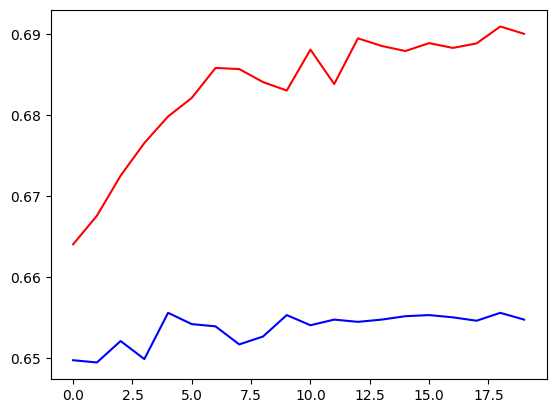

In [8]:
plt.plot(history.history['accuracy'],color='red',label='accuracy')
plt.plot(history.history['val_accuracy'],color='blue',label='val-accuracy')
plt.show()

In [5]:
model.save('trained.keras')

In [6]:
y_pred=model.predict(test_generator)

113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step


In [7]:
y_pred=np.argmax(y_pred,axis=1)
y_true=test_generator.classes


In [8]:
from sklearn.metrics import classification_report
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.13      0.99      0.24       958
           1       0.00      0.00      0.00       111
           2       0.11      0.00      0.01      1024
           3       0.00      0.00      0.00      1774
           4       0.00      0.00      0.00      1233
           5       0.00      0.00      0.00      1247
           6       0.14      0.01      0.01       831

    accuracy                           0.13      7178
   macro avg       0.06      0.14      0.04      7178
weighted avg       0.05      0.13      0.03      7178



c:\Users\User\Desktop\ZenithView\ai_engine\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Desktop\ZenithView\ai_engine\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Desktop\ZenithView\ai_engine\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [9]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_true,y_pred))

[[ 948    0    7    0    0    1    2]
 [ 110    0    1    0    0    0    0]
 [1016    0    4    0    0    1    3]
 [1759    1    7    0    0    1    6]
 [1219    0    9    0    0    0    5]
 [1228    0    4    0    0    0   15]
 [ 823    0    3    0    0    0    5]]


In [10]:
model.save('Video.keras')